In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [52]:
# Load data
df = pd.read_csv("Supabase Snippet Worklogs Cleanup.csv")

# Parse month
df["month"] = pd.to_datetime(df["month"], utc=True)

# Exclude incomplete month (April 2026)
df = df[df["month"] != pd.Timestamp("2026-04-01", tz="UTC")].copy()

# Create readable calendar fields
df["year"] = df["month"].dt.year
df["month_of_year"] = df["month"].dt.month
df["year_month"] = df["month"].dt.strftime("%Y-%m")

# Keep a numeric month index for modeling
df["month_num"] = df["year"] * 12 + df["month_of_year"]

# Seasonality features (cyclical encoding)
df["month_sin"] = np.sin(2 * np.pi * df["month_of_year"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_of_year"] / 12)

# Define features (X) and target (y)
X = df[["month_num", "active_users", "month_sin", "month_cos"]]
y = df["total_hours"]

print("Rows after filtering:", len(df))
print("X shape:", X.shape)
print("y shape:", y.shape)
display(df[["year_month", "month_of_year", "active_users", "month_sin", "month_cos", "total_hours"]].tail(8))

Rows after filtering: 28
X shape: (28, 4)
y shape: (28,)


,year_month,month_of_year,active_users,month_sin,month_cos,total_hours
20,2025-08,8,20,-8.660254e-01,-5.000000e-01,2296.816667
21,2025-09,9,20,-1.000000e+00,-1.836970e-16,2541.800000
22,2025-10,10,22,-8.660254e-01,5.000000e-01,2735.400000
23,2025-11,11,21,-5.000000e-01,8.660254e-01,2641.066667
24,2025-12,12,19,-2.449294e-16,1.000000e+00,2277.833333
25,2026-01,1,20,5.000000e-01,8.660254e-01,2502.150000
26,2026-02,2,21,8.660254e-01,5.000000e-01,2645.316667
27,2026-03,3,18,1.000000e+00,6.123234e-17,1241.250000


In [53]:
# Split data: latest 6 months as validation (time-series aware, no shuffle)
n = len(df)
val_size = 6

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=val_size, shuffle=False
)

print(f"Total rows: {n}")
print(f"Train rows: {len(X_train)}")
print(f"Val rows: {len(X_val)}")

train_start = df.iloc[0]["year_month"]
train_end = df.iloc[len(X_train)-1]["year_month"]
val_start = df.iloc[len(X_train)]["year_month"]
val_end = df.iloc[len(X_train)+len(X_val)-1]["year_month"]

print("\nTrain period:", train_start, "->", train_end)
print("Val period:  ", val_start, "->", val_end)

display(X_train.tail())
display(X_val)

Total rows: 28
Train rows: 22
Val rows: 6

Train period: 2023-12 -> 2025-09
Val period:   2025-10 -> 2026-03


,month_num,active_users,month_sin,month_cos
17,24305,24,5.000000e-01,-8.660254e-01
18,24306,23,1.224647e-16,-1.000000e+00
19,24307,19,-5.000000e-01,-8.660254e-01
20,24308,20,-8.660254e-01,-5.000000e-01
21,24309,20,-1.000000e+00,-1.836970e-16


,month_num,active_users,month_sin,month_cos
22,24310,22,-8.660254e-01,5.000000e-01
23,24311,21,-5.000000e-01,8.660254e-01
24,24312,19,-2.449294e-16,1.000000e+00
25,24313,20,5.000000e-01,8.660254e-01
26,24314,21,8.660254e-01,5.000000e-01
27,24315,18,1.000000e+00,6.123234e-17


In [54]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train and compare multiple models
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
print(f"Best model by RMSE: {best_model_name}")

# Build a simple future feature set (next 6 months)
horizon = 6
last_month = df["month"].max()
future_months = pd.date_range(
    start=last_month + pd.offsets.MonthBegin(1), periods=horizon, freq="MS", tz="UTC"
)

# Scenario for future active_users: use mean of latest 6 observed months
future_active_users = int(round(df["active_users"].tail(6).mean()))

future_df = pd.DataFrame({
    "month": future_months,
})
future_df["year"] = future_df["month"].dt.year
future_df["month_of_year"] = future_df["month"].dt.month
future_df["year_month"] = future_df["month"].dt.strftime("%Y-%m")
future_df["month_num"] = future_df["year"] * 12 + future_df["month_of_year"]
future_df["month_sin"] = np.sin(2 * np.pi * future_df["month_of_year"] / 12)
future_df["month_cos"] = np.cos(2 * np.pi * future_df["month_of_year"] / 12)
future_df["active_users"] = future_active_users

X_future = future_df[["month_num", "active_users", "month_sin", "month_cos"]]
future_df["pred_total_hours"] = best_model.predict(X_future).round(1)

print(f"Forecast horizon: {horizon} months")
print(f"Assumed active_users each month: {future_active_users}")
display(future_df[["year_month", "month_of_year", "active_users", "pred_total_hours"]])

,model,MAE,RMSE
0,RandomForest,647.512296,923.360981
1,Ridge,1167.284981,1258.999811
2,LinearRegression,1191.974432,1285.847000


Best model by RMSE: RandomForest
Forecast horizon: 6 months
Assumed active_users each month: 20


,year_month,month_of_year,active_users,pred_total_hours
0,2026-04,4,20,3257.9
1,2026-05,5,20,3307.2
2,2026-06,6,20,2854.2
3,2026-07,7,20,2534.7
4,2026-08,8,20,2457.3
5,2026-09,9,20,2501.8


In [55]:
# Seasonality profile: average total hours by calendar month
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

seasonality_df = (
    df.groupby("month_of_year", as_index=False)
      .agg(
          avg_total_hours=("total_hours", "mean"),
          avg_active_users=("active_users", "mean"),
          observations=("total_hours", "count")
      )
      .sort_values("month_of_year")
)
seasonality_df["month_name"] = seasonality_df["month_of_year"].map(month_names)
seasonality_df = seasonality_df[["month_of_year", "month_name", "avg_total_hours", "avg_active_users", "observations"]]

best_month = seasonality_df.loc[seasonality_df["avg_total_hours"].idxmax()]
worst_month = seasonality_df.loc[seasonality_df["avg_total_hours"].idxmin()]

print("Seasonality summary (historical averages)")
print(f"Highest avg month: {best_month['month_name']} ({best_month['avg_total_hours']:.1f} hours)")
print(f"Lowest avg month: {worst_month['month_name']} ({worst_month['avg_total_hours']:.1f} hours)")

display(seasonality_df)

Seasonality summary (historical averages)
Highest avg month: Apr (4456.6 hours)
Lowest avg month: Dec (2323.8 hours)


,month_of_year,month_name,avg_total_hours,avg_active_users,observations
0,1,Jan,3326.050000,24.666667,3
1,2,Feb,3684.522222,26.666667,3
2,3,Mar,3360.900000,25.666667,3
3,4,Apr,4456.650000,30.000000,2
4,5,May,4293.650000,29.000000,2
5,6,Jun,3734.325000,28.500000,2
6,7,Jul,2541.916667,22.000000,2
7,8,Aug,3143.551667,24.500000,2
8,9,Sep,3295.450000,24.000000,2
9,10,Oct,3830.365000,26.500000,2


In [56]:
# Confidence estimate via validation residuals (prediction intervals)
y_val_pred = best_model.predict(X_val)
val_residuals = y_val - y_val_pred

# Absolute residual quantiles for interval widths
q80 = np.quantile(np.abs(val_residuals), 0.80)
q95 = np.quantile(np.abs(val_residuals), 0.95)

# Add confidence intervals to future forecast
future_df["pred_low_80"] = (future_df["pred_total_hours"] - q80).round(1)
future_df["pred_high_80"] = (future_df["pred_total_hours"] + q80).round(1)
future_df["pred_low_95"] = (future_df["pred_total_hours"] - q95).round(1)
future_df["pred_high_95"] = (future_df["pred_total_hours"] + q95).round(1)

# Backtest-style confidence score on validation set (coverage)
val_low_80 = y_val_pred - q80
val_high_80 = y_val_pred + q80
val_low_95 = y_val_pred - q95
val_high_95 = y_val_pred + q95

coverage_80 = ((y_val >= val_low_80) & (y_val <= val_high_80)).mean()
coverage_95 = ((y_val >= val_low_95) & (y_val <= val_high_95)).mean()

print("Confidence summary (validation-based)")
print(f"80% interval coverage on val: {coverage_80:.1%}")
print(f"95% interval coverage on val: {coverage_95:.1%}")

display(future_df[[
    "year_month",
    "pred_total_hours",
    "pred_low_80", "pred_high_80",
    "pred_low_95", "pred_high_95"
]])

Confidence summary (validation-based)
80% interval coverage on val: 83.3%
95% interval coverage on val: 83.3%


,year_month,pred_total_hours,pred_low_80,pred_high_80,pred_low_95,pred_high_95
0,2026-04,3257.9,2576.0,3939.8,1559.3,4956.5
1,2026-05,3307.2,2625.3,3989.1,1608.6,5005.8
2,2026-06,2854.2,2172.3,3536.1,1155.6,4552.8
3,2026-07,2534.7,1852.8,3216.6,836.1,4233.3
4,2026-08,2457.3,1775.4,3139.2,758.7,4155.9
5,2026-09,2501.8,1819.9,3183.7,803.2,4200.4


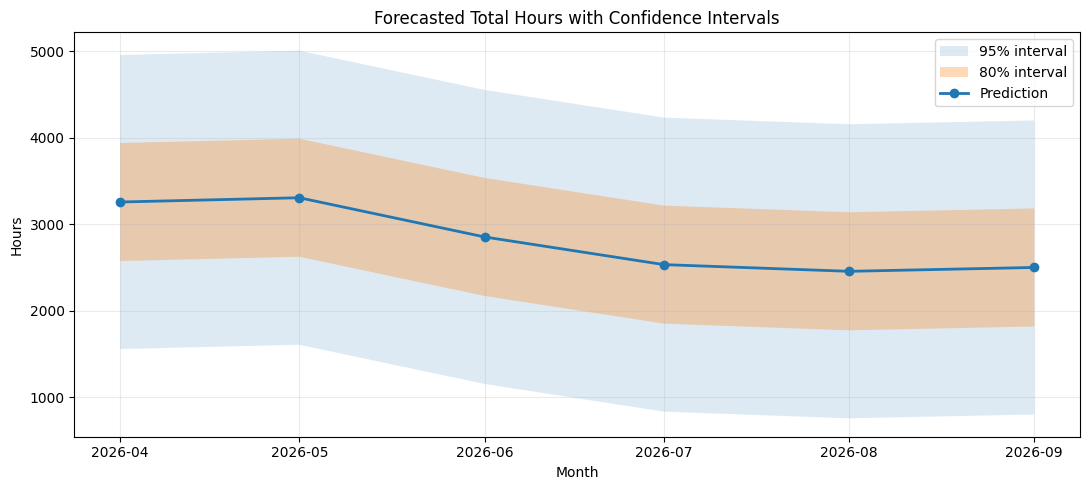

C:\Users\kaspe\AppData\Local\Temp\ipykernel_8764\3333323755.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], patch_artist=True)


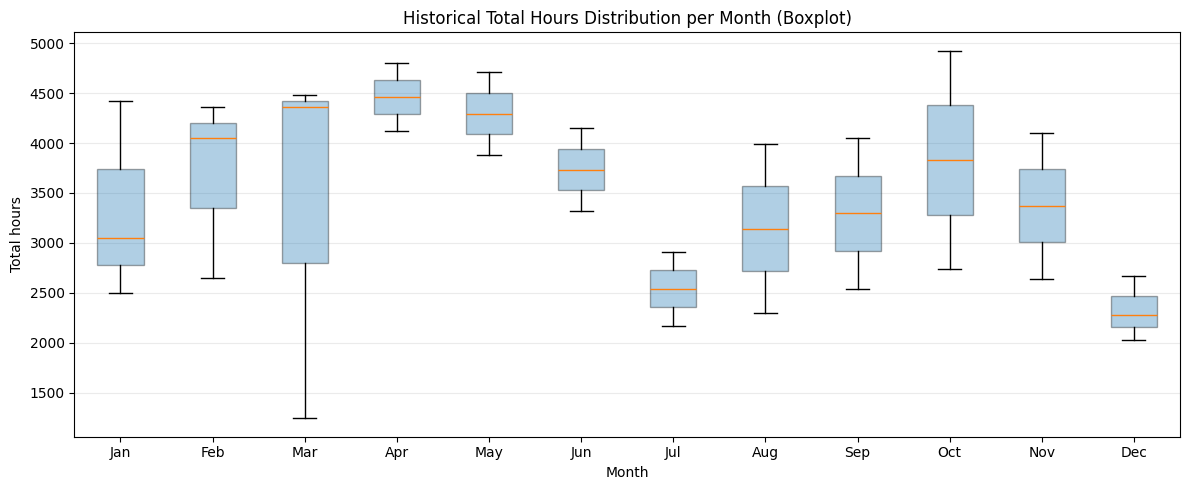

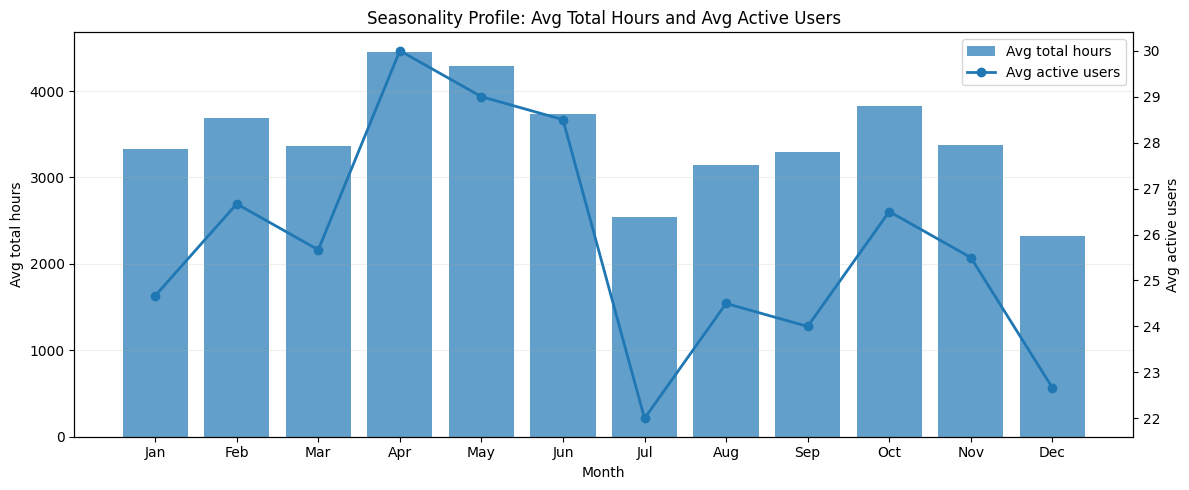

In [57]:
import matplotlib.pyplot as plt

# ---- Plot 1: Forecast with 80/95% uncertainty bands ----
plot_df = future_df.copy()
plot_df["month_date"] = pd.to_datetime(plot_df["year_month"] + "-01")

plt.figure(figsize=(11, 5))
plt.fill_between(
    plot_df["month_date"],
    plot_df["pred_low_95"],
    plot_df["pred_high_95"],
    alpha=0.15,
    label="95% interval"
    )
plt.fill_between(
    plot_df["month_date"],
    plot_df["pred_low_80"],
    plot_df["pred_high_80"],
    alpha=0.30,
    label="80% interval"
    )
plt.plot(plot_df["month_date"], plot_df["pred_total_hours"], marker="o", linewidth=2, label="Prediction")
plt.title("Forecasted Total Hours with Confidence Intervals")
plt.xlabel("Month")
plt.ylabel("Hours")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 2: Historical boxplot by calendar month (real spread) ----
hist_box = df[["month_of_year", "total_hours"]].copy()
box_data = [hist_box.loc[hist_box["month_of_year"] == m, "total_hours"].values for m in range(1, 13)]

plt.figure(figsize=(12, 5))
bp = plt.boxplot(box_data, labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], patch_artist=True)
for patch in bp["boxes"]:
    patch.set_alpha(0.35)
plt.title("Historical Total Hours Distribution per Month (Boxplot)")
plt.xlabel("Month")
plt.ylabel("Total hours")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ---- Plot 3: Seasonality profile (avg hours + avg active users) ----
fig, ax1 = plt.subplots(figsize=(12, 5))
x_labels = seasonality_df["month_name"]
x_idx = np.arange(len(x_labels))

bars = ax1.bar(x_idx, seasonality_df["avg_total_hours"], alpha=0.7, label="Avg total hours")
ax1.set_title("Seasonality Profile: Avg Total Hours and Avg Active Users")
ax1.set_xlabel("Month")
ax1.set_ylabel("Avg total hours")
ax1.set_xticks(x_idx)
ax1.set_xticklabels(x_labels)
ax1.grid(axis="y", alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(x_idx, seasonality_df["avg_active_users"], marker="o", linewidth=2, label="Avg active users")
ax2.set_ylabel("Avg active users")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right")
fig.tight_layout()
plt.show()